In [10]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = {
    'review': [
        'great product loved it works perfectly',
        'excellent quality fast delivery very happy',
        'amazing value for money will buy again',
        'awesome build quality highly recommend',
        'worst product ever totally disappointed',
        'bad quality stopped working in two days',
        'terrible experience waste of money',
        'poor packaging item arrived damaged',
        'good product but delivery was late',
        'not satisfied product quality is low'
    ],
    'sentiment': [
        'positive', 'positive', 'positive', 'positive',
        'negative', 'negative', 'negative', 'negative',
        'positive', 'negative'
    ]
}

df = pd.DataFrame(data)
df.to_csv('filpkart_reviews.csv' , index = False)
df.head(2)

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['review'])
y= df['sentiment']

X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size = 0.3 , random_state=42
)

knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train , y_train)

y_pred = knn.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.3333333333333333


In [29]:

import pandas as pd 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

df = pd.read_csv('spotify_top50.csv' , encoding = 'latin1')

df.head(2)

X = df.drop('Popularity' , axis = 1).select_dtypes(include = ['int64' , 'float64'])
y = df['Popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Euclidean
knn_euclidean = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
knn_euclidean.fit(X_train_s, y_train)
acc_euclidean = accuracy_score(y_test, knn_euclidean.predict(X_test_s))


knn_manhattan = KNeighborsClassifier(n_neighbors=3, metric='manhattan')
knn_manhattan.fit(X_train_s, y_train)
acc_manhattan = accuracy_score(y_test, knn_manhattan.predict(X_test_s))

print(knn_euclidean)  
print(knn_manhattan)

print(f"Euclidean Accuracy: {acc_euclidean:.4f}")
print(f"Manhattan Accuracy: {acc_manhattan:.4f}")

KNeighborsClassifier(metric='euclidean', n_neighbors=3)
KNeighborsClassifier(metric='manhattan', n_neighbors=3)
Euclidean Accuracy: 0.0667
Manhattan Accuracy: 0.0000


In [30]:

import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = {
    'booking_days_before': [60, 45, 30, 10, 5, 50, 40, 8, 3, 55],
    'train_popularity'   : [3, 5, 7, 9, 10, 2, 6, 8, 10, 4],   # 1-10 scale
    'travel_day_weekend'  : [0, 0, 1, 1, 1, 0, 0, 1, 1, 0],     # 1=weekend
    'status'              : ['confirmed','confirmed','waitlisted','waitlisted',
                             'waitlisted','confirmed','confirmed','waitlisted',
                             'waitlisted','confirmed']
}

df = pd.DataFrame(data)
df.to_csv('irctc_booking.csv', index=False)
print(df)

X = df[['booking_days_before', 'train_popularity', 'travel_day_weekend']]
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))


new_booking = [[7, 9, 1]]   
print("Prediction:", model.predict(new_booking))

   booking_days_before  train_popularity  travel_day_weekend      status
0                   60                 3                   0   confirmed
1                   45                 5                   0   confirmed
2                   30                 7                   1  waitlisted
3                   10                 9                   1  waitlisted
4                    5                10                   1  waitlisted
5                   50                 2                   0   confirmed
6                   40                 6                   0   confirmed
7                    8                 8                   1  waitlisted
8                    3                10                   1  waitlisted
9                   55                 4                   0   confirmed

Accuracy: 1.0
Prediction: ['waitlisted']


/opt/anaconda3/envs/myenv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(



Accuracy: 0.25


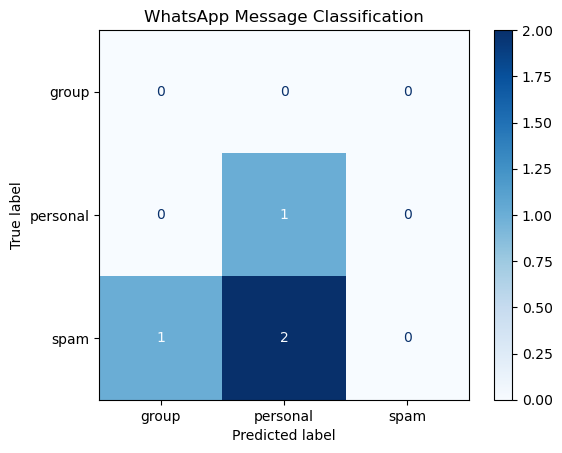

In [37]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

data = {
    'message': [
        'hey how are you doing today',
        'are we still meeting for lunch',
        'happy birthday have a great day',
        'call me when you are free',
        'group meeting scheduled for 5pm today',
        'everyone please submit the report by friday',
        'team lunch this saturday at noon',
        'project deadline moved to next week',
        'congratulations you have won a free prize claim now',
        'limited offer click link to win cash now',
        'urgent verify your account or it will be suspended',
        'you have been selected for a lottery winner prize'
    ],
    'category': [
        'personal','personal','personal','personal',
        'group','group','group','group',
        'spam','spam','spam','spam'
    ]
}

df = pd.DataFrame(data)
df.to_csv('whatsapp_messages.csv', index=False)
df.head(2)

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['message'])
y = df['category']

df.head(2)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
ConfusionMatrixDisplay(cm, display_labels=model.classes_).plot(cmap='Blues')
plt.title('WhatsApp Message Classification')
plt.show()